In [11]:
import re
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

nltk.download("stopwords")
nltk.download("wordnet")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HFCS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HFCS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [14]:
dataset = load_dataset("ag_news")
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

label_map = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
train_df["label_name"] = train_df["label"].map(label_map)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (120000, 3)
Test shape: (7600, 2)


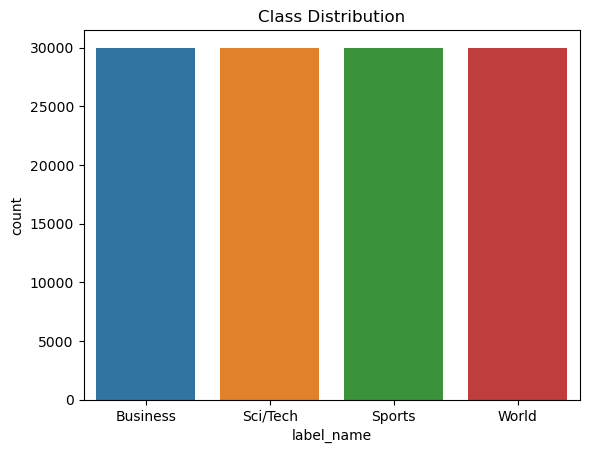

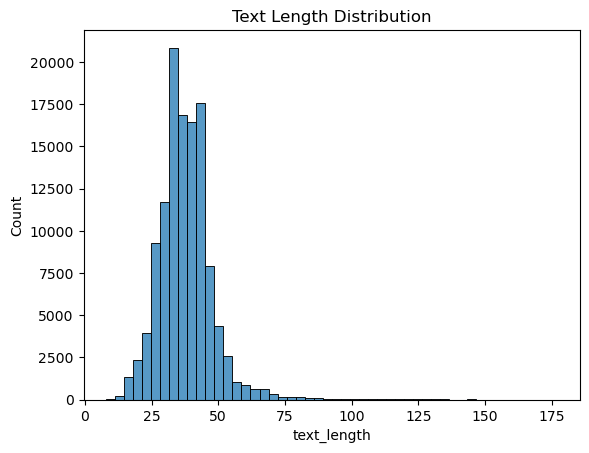

              count       mean        std   min   25%   50%   75%    max
label_name                                                              
Business    30000.0  37.538233   8.121983   8.0  32.0  37.0  42.0  134.0
Sci/Tech    30000.0  37.191967  12.417603   8.0  30.0  36.0  42.0  177.0
Sports      30000.0  37.774733   8.870100   8.0  32.0  37.0  42.0  151.0
World       30000.0  38.884867  10.315517  11.0  33.0  39.0  44.0  145.0


In [16]:
sns.countplot(x="label_name", data=train_df)
plt.title("Class Distribution")
plt.show()

train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))
sns.histplot(train_df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

print(train_df.groupby("label_name")["text_length"].describe())


In [17]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)


In [18]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(tokens)

train_df["processed_text"] = train_df["clean_text"].apply(preprocess)
test_df["processed_text"] = test_df["clean_text"].apply(preprocess)

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_full = vectorizer.fit_transform(train_df["processed_text"])
y_train_full = train_df["label"]
X_test = vectorizer.transform(test_df["processed_text"])
y_test = test_df["label"]

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

In [19]:
baseline_model = MultinomialNB()
baseline_model.fit(X_tr, y_tr)
baseline_acc = baseline_model.score(X_val, y_val)
print(f"\nBaseline (Naive Bayes) Accuracy: {baseline_acc:.4f}")

# ---------- 7. Advanced Models ----------
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_tr, y_tr)
print(f"Logistic Regression Accuracy: {log_reg.score(X_val, y_val):.4f}")

svm_model = LinearSVC()
svm_model.fit(X_tr, y_tr)
print(f"Linear SVM Accuracy: {svm_model.score(X_val, y_val):.4f}")

best_model = svm_model



Baseline (Naive Bayes) Accuracy: 0.9097
Logistic Regression Accuracy: 0.9224
Linear SVM Accuracy: 0.9204



Classification Report:

              precision    recall  f1-score   support

       World       0.93      0.91      0.92      6000
      Sports       0.96      0.98      0.97      6000
    Business       0.89      0.89      0.89      6000
    Sci/Tech       0.90      0.90      0.90      6000

    accuracy                           0.92     24000
   macro avg       0.92      0.92      0.92     24000
weighted avg       0.92      0.92      0.92     24000



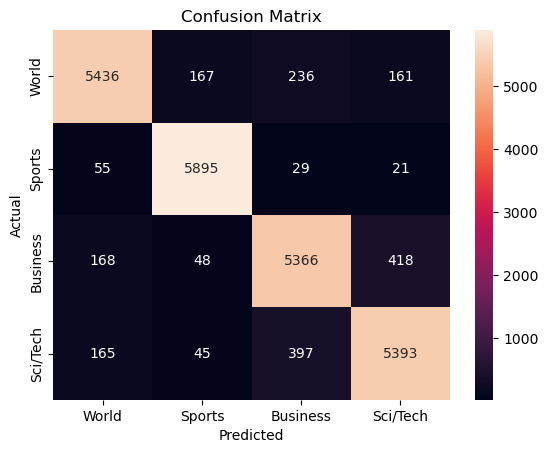

In [20]:
y_pred = best_model.predict(X_val)

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred, target_names=label_map.values()))

cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=label_map.values(), yticklabels=label_map.values())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
test_acc = best_model.score(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")


In [21]:
val_indices = y_val.index
val_df = train_df.loc[val_indices].copy()
val_df["predicted"] = y_pred
val_df["predicted_name"] = val_df["predicted"].map(label_map)

errors = val_df[val_df["predicted"] != val_df["label"]]
print(f"\nNumber of error : {len(errors)} from {len(val_df)}")
print(errors[["text", "label_name", "predicted_name"]].sample(min(10, len(errors))))




Number of error : 1910 from 24000
                                                     text label_name  \
52030   Winter Weather Outlook Mixed, El Nino Looms (R...   Sci/Tech   
36805   Cabrera's Homer Leads Red Sox Past Orioles Orl...      World   
110976  Laptops may damage male fertility Men who use ...      World   
45635   AT amp;T to Offer Service at Circuit City Tele...   Sci/Tech   
66906   DEA Disavows Support Of Painkiller Guidelines ...   Sci/Tech   
112689  Video Gamer Makers Undeterred by Mixed Sales D...   Business   
108242  Report: IBM Selling Its PC Business China's la...   Sci/Tech   
62483   COAST TO COAST The FBI and New York police det...   Business   
15686   Fujitsu Limited Ad-hoc-Mitteilung verarbeitet ...   Sci/Tech   
59471   WorldCom's Ebbers Wants Company to Pay Legal B...   Sci/Tech   

       predicted_name  
52030        Business  
36805          Sports  
110976       Sci/Tech  
45635        Business  
66906           World  
112689       Sci/Tech  
1082

In [25]:
error_pairs = errors.groupby(["label_name", "predicted_name"]).size().sort_values(ascending=False)
print(error_pairs.head(10))


label_name  predicted_name
Business    Sci/Tech          418
Sci/Tech    Business          397
World       Business          236
Business    World             168
World       Sports            167
Sci/Tech    World             165
World       Sci/Tech          161
Sports      World              55
Business    Sports             48
Sci/Tech    Sports             45
dtype: int64


In [26]:
joblib.dump(best_model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")


['vectorizer.pkl']

In [7]:
!pip install datasets

     ------------------------------------ 515.2/515.2 kB 283.5 kB/s eta 0:00:00
     -------------------------------------- 80.2/80.2 kB 559.7 kB/s eta 0:00:00
     ------------------------------------ 133.5/133.5 kB 524.4 kB/s eta 0:00:00
     -------------------------------------- 64.7/64.7 kB 579.8 kB/s eta 0:00:00
     ------------------------------------ 201.0/201.0 kB 436.4 kB/s eta 0:00:00
     ------------------------------------ 625.2/625.2 kB 579.1 kB/s eta 0:00:00
     ------------------------------------ 463.1/463.1 kB 762.4 kB/s eta 0:00:00
     ---------------------------------------- 4.0/4.0 MB 1.1 MB/s eta 0:00:00
     -------------------------------------- 119.7/119.7 kB 1.0 MB/s eta 0:00:00
     -------------------------------------- 44.1/44.1 kB 720.9 kB/s eta 0:00:00
     -------------------------------------- 41.9/41.9 kB 989.7 kB/s eta 0:00:00
     -------------------------------------- 87.1/87.1 kB 986.0 kB/s eta 0:00:00
     -------------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
anaconda-project 0.11.1 requires ruamel-yaml, which is not installed.
conda-repo-cli 1.0.20 requires clyent==1.2.1, but you have clyent 1.2.2 which is incompatible.
conda-repo-cli 1.0.20 requires nbformat==5.4.0, but you have nbformat 5.5.0 which is incompatible.
conda-repo-cli 1.0.20 requires requests==2.28.1, but you have requests 2.32.5 which is incompatible.


In [9]:
from datasets import load_dataset
dataset = load_dataset("ag_news")

README.md: 0.00B [00:00, ?B/s]

C:\Users\HFCS\anaconda3\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\HFCS\.cache\huggingface\hub\datasets--ag_news. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]